In [1]:
import pandas as pd
import matplotlib as pyplt
df_company = pd.read_csv("../data/raw/ai_company_adoption.csv")
df_industry = pd.read_csv("../data/raw/ai_industry_summary.csv")
df_country = pd.read_csv("../data/raw/country_ai_index.csv")

In [2]:
columns = [
    "ai_adoption_rate",
    "productivity_change_percent",
    "ai_maturity_score"
]

In [3]:
correlation_matrix = df_company[columns].corr()

correlation_matrix

,ai_adoption_rate,productivity_change_percent,ai_maturity_score
ai_adoption_rate,1.000000,0.674973,0.841339
productivity_change_percent,0.674973,1.000000,0.737314
ai_maturity_score,0.841339,0.737314,1.000000


In [4]:
correlation_matrix.round(2)

,ai_adoption_rate,productivity_change_percent,ai_maturity_score
ai_adoption_rate,1.00,0.67,0.84
productivity_change_percent,0.67,1.00,0.74
ai_maturity_score,0.84,0.74,1.00


In [5]:
print("=" * 60)
print("Correlation Analysis")
print("=" * 60)

print("AI Adoption Rate ↔ Productivity Change :",
      round(correlation_matrix.loc["ai_adoption_rate",
                                   "productivity_change_percent"], 3))

print("AI Adoption Rate ↔ AI Maturity Score :",
      round(correlation_matrix.loc["ai_adoption_rate",
                                   "ai_maturity_score"], 3))

print("Productivity Change ↔ AI Maturity Score :",
      round(correlation_matrix.loc["productivity_change_percent",
                                   "ai_maturity_score"], 3))

Correlation Analysis
AI Adoption Rate ↔ Productivity Change : 0.675
AI Adoption Rate ↔ AI Maturity Score : 0.841
Productivity Change ↔ AI Maturity Score : 0.737


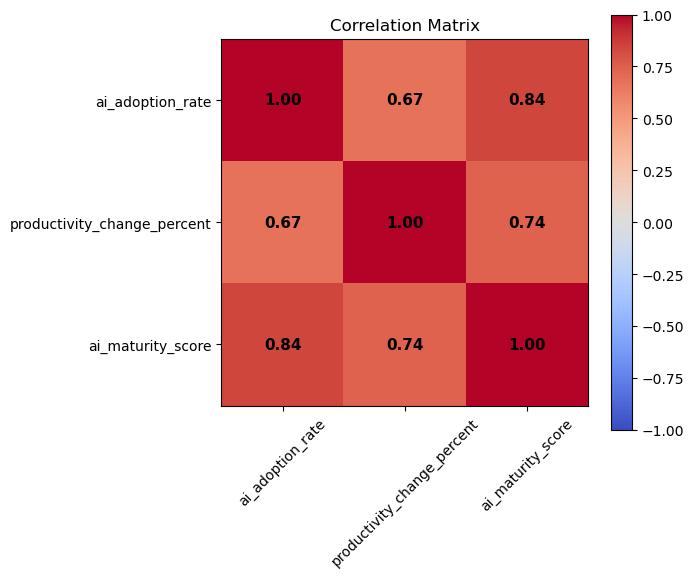

In [7]:
import matplotlib.pyplot as plt

columns = [
    "ai_adoption_rate",
    "productivity_change_percent",
    "ai_maturity_score"
]

corr = df_company[columns].corr()

plt.figure(figsize=(7,6))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar()

plt.xticks(range(len(columns)), columns, rotation=45)
plt.yticks(range(len(columns)), columns)

# Display correlation values inside each cell
for i in range(len(columns)):
    for j in range(len(columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=11,
            fontweight="bold"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

#### Business Conclusion

The heatmap shows that all three variables are positively related.

Among them:

### Strongest relationship: AI Adoption Rate ↔ AI Maturity Score (0.84)
### Second strongest: Productivity Change ↔ AI Maturity Score (0.74)
### Third strongest: AI Adoption Rate ↔ Productivity Change (0.67)

This suggests that companies with higher AI adoption are generally more AI-mature, and both higher adoption and higher maturity are associated with better productivity.

#### tassk 2 Variance analysis across region, survey_source

#### Variance

Variance measures how spread out the values are around the mean.

- Low Variance
- Values are close to the average.
- Indicates consistency.
### High Variance
- Values are spread over a wider range.
- Indicates greater variability.

### Variance analysis helps identify:

- Consistent groups.
- Highly variable groups.
- Regions or survey sources where AI adoption and productivity differ significantly.

- This information is valuable for comparing business performance across categories.

In [8]:
### Calculate Variance by Region
variance_region = df_company.groupby("region")[[
    "ai_adoption_rate",
    "productivity_change_percent",
    "ai_maturity_score"
]].var().round(2)

variance_region

,ai_adoption_rate,productivity_change_percent,ai_maturity_score
region,,,
Africa,210.10,30.82,0.02
Asia,209.53,31.74,0.02
Europe,208.94,31.87,0.02
North America,210.76,32.36,0.02
Oceania,213.42,32.70,0.02
South America,207.98,30.97,0.02


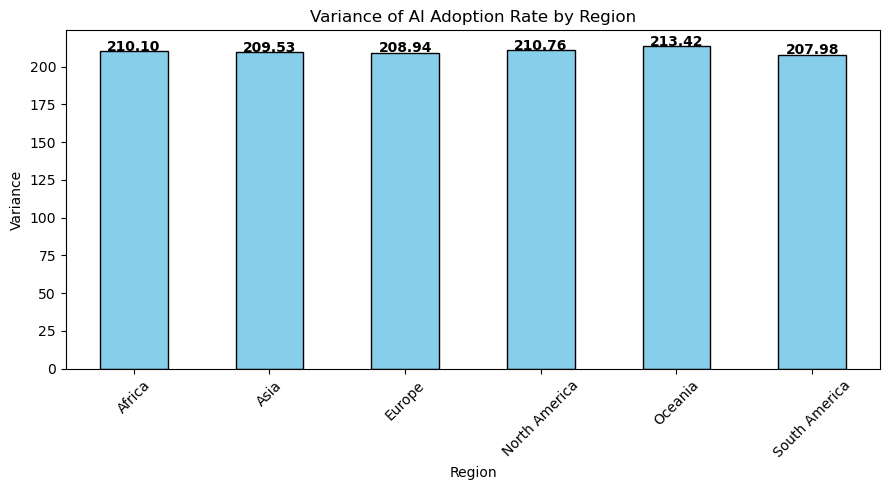

In [10]:
### Display as a Bar Chart
## AI Adoption Rate Variance by Region
plt.figure(figsize=(9,5))

ax = variance_region["ai_adoption_rate"].plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Variance of AI Adoption Rate by Region")
plt.xlabel("Region")
plt.ylabel("Variance")
plt.xticks(rotation=45)

# Add values on bars
for i, value in enumerate(variance_region["ai_adoption_rate"]):
    ax.text(i, value + 0.5, f"{value:.2f}",
            ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In [15]:
variance_region = df_company.groupby("region")[[
    "ai_adoption_rate",
    "productivity_change_percent",
    "ai_maturity_score"
]].var()

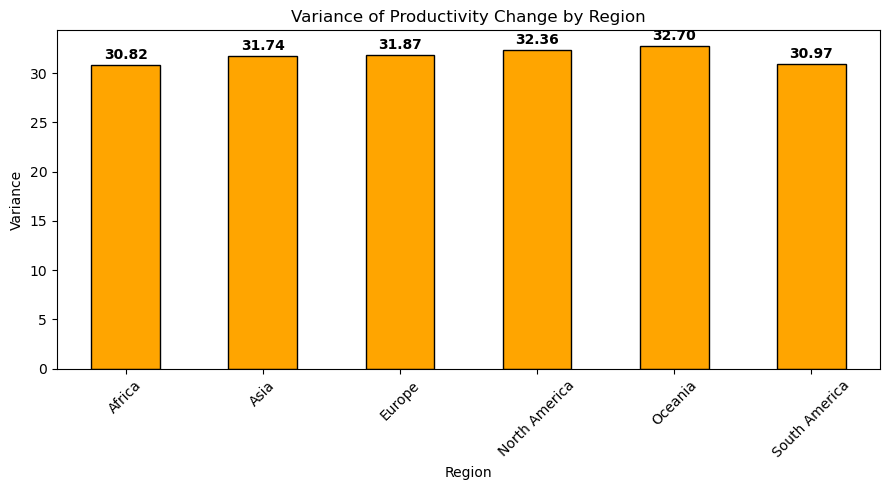

In [16]:
### Productivity Change Variance by Region
plt.figure(figsize=(9,5))

ax = variance_region["productivity_change_percent"].plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Variance of Productivity Change by Region")
plt.xlabel("Region")
plt.ylabel("Variance")

plt.xticks(rotation=45)

for i, value in enumerate(variance_region["productivity_change_percent"]):
    ax.text(
        i,
        value + 0.3,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [18]:
### AI Maturity Score Variance by Region

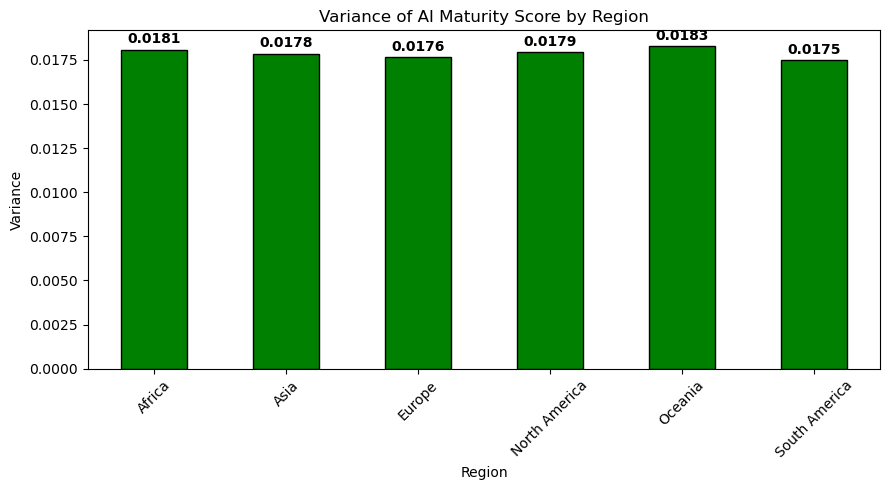

In [17]:
plt.figure(figsize=(9,5))

ax = variance_region["ai_maturity_score"].plot(
    kind="bar",
    color="green",
    edgecolor="black"
)

plt.title("Variance of AI Maturity Score by Region")
plt.xlabel("Region")
plt.ylabel("Variance")

plt.xticks(rotation=45)

for i, value in enumerate(variance_region["ai_maturity_score"]):
    ax.text(
        i,
        value + 0.0002,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [14]:
print(variance_region)

               ai_adoption_rate  productivity_change_percent  \
region                                                         
Africa                   210.10                        30.82   
Asia                     209.53                        31.74   
Europe                   208.94                        31.87   
North America            210.76                        32.36   
Oceania                  213.42                        32.70   
South America            207.98                        30.97   

               ai_maturity_score  
region                            
Africa                      0.02  
Asia                        0.02  
Europe                      0.02  
North America               0.02  
Oceania                     0.02  
South America               0.02  


In [20]:
### Calculate Variance by Survey Source
variance_survey = df_company.groupby("survey_source")[[
    "ai_adoption_rate",
    "productivity_change_percent",
    "ai_maturity_score"
]].var()

variance_survey

,ai_adoption_rate,productivity_change_percent,ai_maturity_score
survey_source,,,
Internal Corporate Survey,210.105289,31.785903,0.017802
LinkedIn Poll,209.060598,31.472459,0.017746
McKinsey Report,213.595089,31.926088,0.018078
WEF Survey,213.409031,31.922964,0.018008


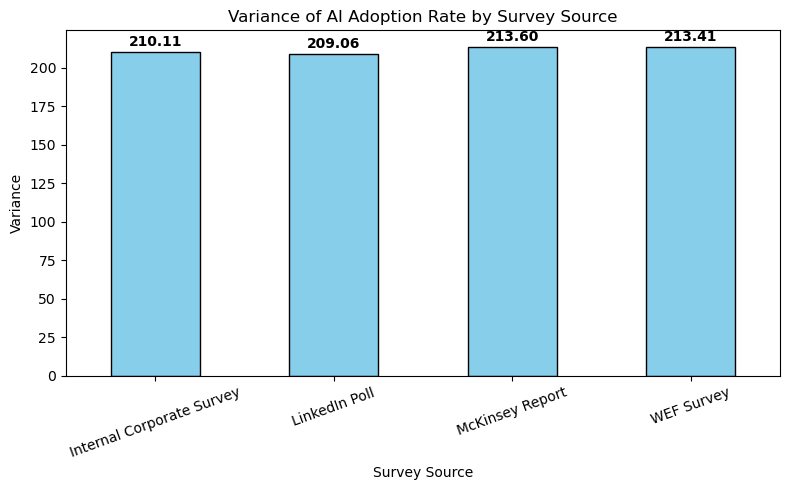

In [21]:
### AI Adoption Rate Variance by Survey Source
plt.figure(figsize=(8,5))

ax = variance_survey["ai_adoption_rate"].plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Variance of AI Adoption Rate by Survey Source")
plt.xlabel("Survey Source")
plt.ylabel("Variance")

plt.xticks(rotation=20)

for i, value in enumerate(variance_survey["ai_adoption_rate"]):
    ax.text(
        i,
        value + 2,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

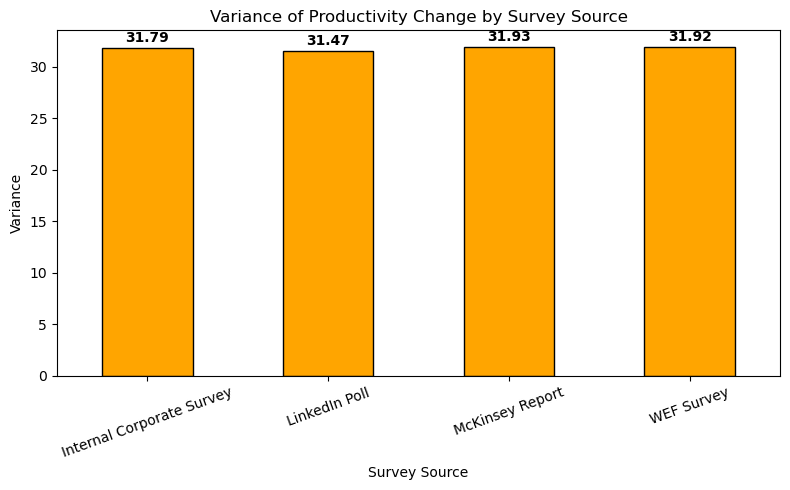

In [22]:
### Productivity Change Variance by Survey Source
plt.figure(figsize=(8,5))

ax = variance_survey["productivity_change_percent"].plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Variance of Productivity Change by Survey Source")
plt.xlabel("Survey Source")
plt.ylabel("Variance")

plt.xticks(rotation=20)

for i, value in enumerate(variance_survey["productivity_change_percent"]):
    ax.text(
        i,
        value + 0.3,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

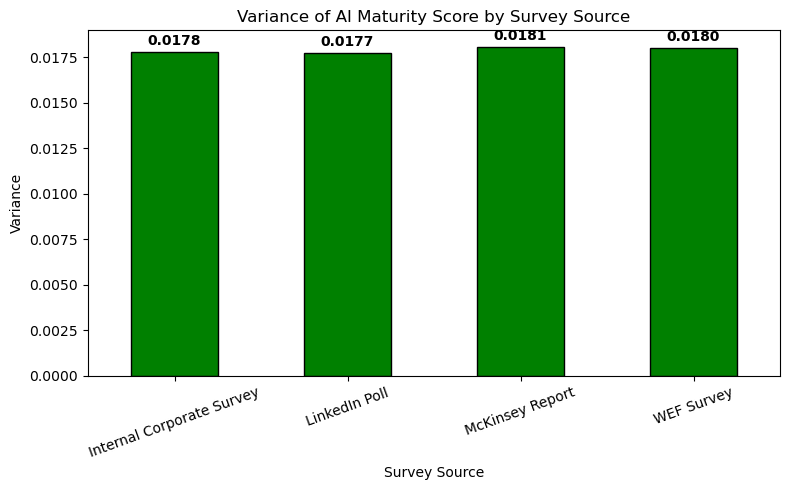

In [23]:
### AI Maturity Score Variance by Survey Source
plt.figure(figsize=(8,5))

ax = variance_survey["ai_maturity_score"].plot(
    kind="bar",
    color="green",
    edgecolor="black"
)

plt.title("Variance of AI Maturity Score by Survey Source")
plt.xlabel("Survey Source")
plt.ylabel("Variance")

plt.xticks(rotation=20)

for i, value in enumerate(variance_survey["ai_maturity_score"]):
    ax.text(
        i,
        value + 0.0002,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Observation
- The variance analysis by survey source compares the variability of AI adoption rate, productivity change percentage, and AI maturity score across different data collection sources. 
- Survey sources with higher variance indicate more diverse responses, while those with lower variance show more consistent results. 
- This analysis helps evaluate the consistency and reliability of the collected survey data.

## Day 15 – Task 3

### Statistical Validation of the Main Hypothesis (Interpret and Note Limitations)

---

# Step 1: Concept

### What is Statistical Validation?

Statistical validation checks whether the **data supports the hypothesis**.

Instead of making assumptions, we use statistical analysis (such as correlation) to determine whether the observed relationships are supported by the dataset.

---

# Step 2: Main Hypothesis

Write this in your notebook:

> **Hypothesis:** Companies with higher AI adoption tend to achieve higher productivity improvements and higher AI maturity.

---

# Step 3: Validate Using Your Correlation Results

Your correlation matrix showed:

| Variables                  | Correlation | Interpretation                |
| -------------------------- | ----------: | ----------------------------- |
| AI Adoption ↔ Productivity |    **0.67** | Moderate Positive Correlation |
| AI Adoption ↔ AI Maturity  |    **0.84** | Strong Positive Correlation   |
| Productivity ↔ AI Maturity |    **0.74** | Strong Positive Correlation   |

---

# Step 4: Statistical Validation Statement

```text
The correlation analysis supports the main hypothesis.

The correlation between AI adoption rate and AI maturity score is 0.84, indicating a strong positive relationship. This suggests that companies with higher AI adoption generally have more mature AI capabilities.

The correlation between AI adoption rate and productivity change percentage is 0.67, indicating a moderate positive relationship. This suggests that higher AI adoption is associated with improved productivity.

The correlation between productivity change percentage and AI maturity score is 0.74, indicating a strong positive relationship. This implies that organizations with more mature AI implementations tend to experience better productivity improvements.

Overall, the statistical analysis supports the hypothesis that AI adoption is positively associated with AI maturity and productivity improvement.
```

---

# Step 5: Project Limitations

Write this in Markdown or as text.

```text
Project Limitations

1. The analysis is based only on the available AI company adoption dataset.

2. Correlation indicates association but does not prove causation.

3. External business factors such as market conditions, organizational culture, and economic changes were not included.

4. The dataset contains survey-based responses that may include reporting bias.

5. The analysis covers a limited time period and may not represent future AI adoption trends.

6. Results should be interpreted within the scope of the available sample.
```

---

# Step 6: Business Conclusion

```text
Business Conclusion

The statistical analysis indicates that AI adoption has positive relationships with both AI maturity and productivity improvement. Organizations with greater AI adoption generally demonstrate higher AI maturity and better productivity outcomes. Although the findings support the project's hypothesis, they should be interpreted carefully because correlation does not establish a cause-and-effect relationship. Additional data and advanced statistical testing would further strengthen these conclusions.
```



In [31]:
import os

print(os.getcwd())
print(os.listdir("../data"))

C:\Users\chinn\OneDrive\Desktop\data analytics internship\AIPulse-Enterprise-AI-Adoption-Business-Performance-Analytics\notebooks
['cleaned', 'raw', 'TASK']


In [39]:
df_company.to_csv("cleaned/ai_company_adoption_clean.csv", index=False)

df_industry.to_csv("cleaned/ai_industry_summary_clean.csv", index=False)

df_country.to_csv("cleaned/country_ai_index_clean.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'cleaned'

In [33]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nContents of Current Folder:")
print(os.listdir())

print("\nDoes 'cleaned' exist?")
print(os.path.exists("cleaned"))

Current Folder:
C:\Users\chinn\OneDrive\Desktop\data analytics internship\AIPulse-Enterprise-AI-Adoption-Business-Performance-Analytics\notebooks

Contents of Current Folder:
['.ipynb_checkpoints', 'day 13.ipynb', 'day 14.ipynb', 'day 15.ipynb', 'Day 2.docx', 'Day 3.ipynb', 'day 4.ipynb', 'day 5.ipynb', 'day 6.ipynb', 'day11_clean.ipynb', 'Day12_EDA_Analysis.ipynb', 'Untitled.ipynb', 'Untitled1.ipynb']

Does 'cleaned' exist?
False


In [34]:
print(os.listdir(".."))

['dashboard', 'data', 'docs', 'excel', 'notebooks', 'sql']


In [35]:
import os

print(os.listdir("../data"))

['cleaned', 'raw', 'TASK']


In [36]:
import os

print(os.listdir("../data/cleaned"))

['ai_company_adoption_clean.csv', 'ai_industry_summary_clean.csv', 'country_ai_index_clean.csv']


In [37]:
import os

print(os.path.abspath("../data/cleaned"))
print(os.path.exists("../data/cleaned"))

C:\Users\chinn\OneDrive\Desktop\data analytics internship\AIPulse-Enterprise-AI-Adoption-Business-Performance-Analytics\data\cleaned
True


In [41]:
df_company.to_csv("../data/cleaned/ai_company_adoption_clean.csv", index=False)

df_industry.to_csv("../data/cleaned/ai_industry_summary_clean.csv", index=False)

df_country.to_csv("../data/cleaned/country_ai_index_clean.csv", index=False)

In [42]:
import os

print(os.listdir("../data/cleaned"))

['ai_company_adoption_clean.csv', 'ai_industry_summary_clean.csv', 'country_ai_index_clean.csv']


In [43]:
company = pd.read_csv("../data/cleaned/ai_company_adoption_clean.csv")
industry = pd.read_csv("../data/cleaned/ai_industry_summary_clean.csv")
country = pd.read_csv("../data/cleaned/country_ai_index_clean.csv")

print(company.shape)
print(industry.shape)
print(country.shape)

(150000, 43)
(9, 8)
(30, 8)


In [44]:
print(company.head())

   response_id  company_id  survey_year quarter country  region   industry  \
0            1  COMP-00001         2023      Q1   Italy  Europe  Education   
1            2  COMP-00001         2023      Q2   Italy  Europe  Education   
2            3  COMP-00001         2023      Q3   Italy  Europe  Education   
3            4  COMP-00001         2023      Q4   Italy  Europe  Education   
4            5  COMP-00001         2024      Q1   Italy  Europe  Education   

  company_size  num_employees  annual_revenue_usd_millions  ...  \
0      Startup             57                        48.31  ...   
1      Startup             57                        48.31  ...   
2      Startup             57                        48.31  ...   
3      Startup             57                        48.31  ...   
4      Startup             57                        48.31  ...   

   productivity_change_percent  jobs_displaced jobs_created  \
0                         2.65               1            1   
1 

In [45]:
company = pd.read_csv("../data/cleaned/ai_company_adoption_clean.csv")
print(company.shape)

industry = pd.read_csv("../data/cleaned/ai_industry_summary_clean.csv")
print(industry.shape)

country = pd.read_csv("../data/cleaned/country_ai_index_clean.csv")
print(country.shape)

(150000, 43)
(9, 8)
(30, 8)


In [46]:
import pandas as pd

raw = pd.read_csv("../data/raw/ai_company_adoption.csv")
clean = pd.read_csv("../data/cleaned/ai_company_adoption_clean.csv")

print("Raw Shape:", raw.shape)
print("Clean Shape:", clean.shape)

print("\nRaw Missing Values:")
print(raw.isnull().sum()[raw.isnull().sum() > 0])

print("\nClean Missing Values:")
print(clean.isnull().sum()[clean.isnull().sum() > 0])

print("\nRaw Duplicates:", raw.duplicated().sum())
print("Clean Duplicates:", clean.duplicated().sum())

Raw Shape: (150000, 43)
Clean Shape: (150000, 43)

Raw Missing Values:
Series([], dtype: int64)

Clean Missing Values:
Series([], dtype: int64)

Raw Duplicates: 0
Clean Duplicates: 0


In [47]:
print(raw.equals(clean))

True
